# 4.20 Meta-Árbol de Decisión para Selección de Hiperparámetros

Basado en el código y enfoque de **`src/arboles/aa102_FinalTrain.ipynb`**, este notebook entrena un **Meta-Modelo de Árbol de Decisión** (`rpart`) sobre los resultados obtenidos de las distintas corridas de **Árboles Azarosos** registradas en `datasets/corridas-arboles-azarosos.csv`.

### Objetivo:
* Analizar la relación entre los hiperparámetros explorados y el rendimiento (`score`) en Kaggle.
* Variables predictoras (hiperparámetros):
  - `feature_fraction`
  - `maxdepth`
  - `minsplit`
  - `minbucket_fraction`
  - `minbucket`
* Variable objetivo:
  - `score` (ganancia obtenida en el leaderboard público de Kaggle).
* Graficar el árbol de decisión con `prp` / `rpart.plot` para identificar visualmente las mejores regiones de hiperparámetros a seleccionar.

#### 1. Limpieza del Ambiente y Carga de Librerías

In [1]:
# Limpieza de memoria y ambiente
rm(list = ls(all.names = TRUE))
gc(full = TRUE, verbose = FALSE)

# Carga de librerías necesarias
require("data.table")
require("rpart")
if (!require("rpart.plot")) install.packages("rpart.plot")
require("rpart.plot")

format(Sys.time(), "%a %b %d %X %Y")

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,657985,35.2,1454514,77.7,1079214,57.7
Vcells,1223533,9.4,8388608,64.0,1975054,15.1


Loading required package: data.table

Loading required package: rpart

Loading required package: rpart.plot



[1] "Mon Aug 24 15:36:28 2026"

#### 2. Configuración de Directorios y Carga del Dataset

In [2]:
# Función para determinar la raíz del proyecto de forma dinámica
find_project_root <- function() {
  curr <- normalizePath(getwd(), winslash = "/")
  while (curr != "/" && curr != dirname(curr)) {
    if (file.exists(file.path(curr, "Dockerfile")) || dir.exists(file.path(curr, "src"))) {
      return(curr)
    }
    curr <- dirname(curr)
  }
  return(normalizePath(getwd(), winslash = "/"))
}

dir_base <- if (dir.exists("/workspace")) "/workspace" else find_project_root()
# archivo_dataset <- file.path(dir_base, "datasets", "corridas-arboles-azarosos.csv")
archivo_dataset <- file.path(dir_base, "datasets", "corridas-arboles-azarosos_solo_exp_04.csv")

cat("Directorio base: ", dir_base, "\n")
cat("Archivo dataset: ", archivo_dataset, "\n\n")

if (!file.exists(archivo_dataset)) {
  stop(sprintf("No se encontró el archivo: %s", archivo_dataset))
}

# Lectura del dataset con los resultados de las corridas
dataset <- fread(archivo_dataset)
cat(sprintf("Total de corridas cargadas: %d\n\n", nrow(dataset)))

# Mostrar vista previa
head(dataset)

Directorio base:  /workspace 
Archivo dataset:  /workspace/datasets/corridas-arboles-azarosos_solo_exp_04.csv 

Total de corridas cargadas: 238



experimento,iter,feature_fraction,maxdepth,minsplit,minbucket_fraction,minbucket,cp,num_trees,archivo,envios_positivos,score
<chr>,<int>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<int>,<chr>,<int>,<int>
exp420_00,21,0.2,8,100,0.2,20,-1,32,KA420_ff_0.20_md_8_ms_100_mb_20_cp_-1.0_32trees.csv,10334,337665
exp420_00,22,0.2,8,100,0.3,30,-1,32,KA420_ff_0.20_md_8_ms_100_mb_30_cp_-1.0_32trees.csv,10413,350998
exp420_00,23,0.2,8,100,0.4,40,-1,32,KA420_ff_0.20_md_8_ms_100_mb_40_cp_-1.0_32trees.csv,10375,340831
exp420_00,24,0.2,8,100,0.5,50,-1,32,KA420_ff_0.20_md_8_ms_100_mb_50_cp_-1.0_32trees.csv,10397,343915
exp420_00,25,0.2,8,200,0.2,40,-1,32,KA420_ff_0.20_md_8_ms_200_mb_40_cp_-1.0_32trees.csv,10398,334665
exp420_00,26,0.2,8,200,0.3,60,-1,32,KA420_ff_0.20_md_8_ms_200_mb_60_cp_-1.0_32trees.csv,10492,333831


#### 3. Selección de Columnas para el Meta-Modelo

Se seleccionan las columnas de hiperparámetros (`feature_fraction`, `maxdepth`, `minsplit`, `minbucket_fraction`, `minbucket`) y la métrica de desempeño (`score`).

In [3]:
campos_modelo <- c(
  "feature_fraction",
  "maxdepth",
  "minsplit",
  "minbucket_fraction",
  "minbucket",
  "score"
)

dtrain_final <- dataset[, ..campos_modelo]

cat("Resumen estadístico de las variables del meta-modelo:\n")
summary(dtrain_final)

Resumen estadístico de las variables del meta-modelo:


 feature_fraction    maxdepth        minsplit     minbucket_fraction
 Min.   :0.1000   Min.   : 6.00   Min.   : 40.0   Min.   :0.2000    
 1st Qu.:0.1500   1st Qu.:10.00   1st Qu.:100.0   1st Qu.:0.2000    
 Median :0.2000   Median :12.00   Median :400.0   Median :0.2000    
 Mean   :0.2398   Mean   :12.54   Mean   :365.4   Mean   :0.2702    
 3rd Qu.:0.2500   3rd Qu.:15.50   3rd Qu.:600.0   3rd Qu.:0.3000    
 Max.   :0.7000   Max.   :20.00   Max.   :800.0   Max.   :0.5000    
   minbucket       score       
 Min.   :  8   Min.   :308498  
 1st Qu.: 20   1st Qu.:335228  
 Median : 80   Median :342165  
 Mean   :103   Mean   :342125  
 3rd Qu.:160   3rd Qu.:348352  
 Max.   :400   Max.   :368248  

#### 4. Configuración de Hiperparámetros del Meta-Árbol

Configuramos los parámetros de control de `rpart` (siguiendo el estilo de `aa102_FinalTrain.ipynb`).

In [4]:
# Parámetros de control para el meta-árbol
param_final <- list(
  cp = -1,         # Complejidad mínima
  minsplit = 8,    # Mínima cantidad de registros en un nodo para hacer split
  minbucket = 2,   # Mínima cantidad de registros en una hoja
  maxdepth = 7     # Profundidad máxima del árbol
)

param_final

$cp
[1] -1

$minsplit
[1] 8

$minbucket
[1] 2

$maxdepth
[1] 7

#### 5. Entrenamiento del Meta-Árbol (`rpart`)

Se entrena el modelo de regresión prediciendo `score` a partir de los hiperparámetros.

In [5]:
# Generación del modelo de árbol de decisión
modelo_final <- rpart(
  formula = score ~ feature_fraction + maxdepth + minsplit + minbucket_fraction + minbucket,
  data = dtrain_final,
  xval = 0,
  control = param_final
)

# Estructura del árbol
print(modelo_final)

cat("\n=========================================\n")
cat("Importancia de las variables (Hiperparámetros):\n")
print(modelo_final$variable.importance)
cat("=========================================\n")

n= 238 

node), split, n, deviance, yval
      * denotes terminal node

  1) root 238 2.182867e+10 342125.1  
    2) maxdepth< 9 32 2.081466e+09 333612.7  
      4) feature_fraction>=0.25 12 8.708670e+08 328109.2  
        8) minbucket< 60 3 2.032596e+08 319970.3 *
        9) minbucket>=60 9 4.026396e+08 330822.2  
         18) feature_fraction< 0.4 3 2.345770e+07 326554.0 *
         19) feature_fraction>=0.4 6 2.972021e+08 332956.3 *
      5) feature_fraction< 0.25 20 6.290794e+08 336914.7  
       10) minbucket>=90 12 1.930946e+08 334234.2  
         20) minbucket_fraction>=0.25 10 1.560781e+08 333498.0  
           40) minbucket< 140 2 1.252944e+06 329706.5 *
           41) minbucket>=140 8 1.188865e+08 334445.9  
             82) minbucket>=220 5 4.336106e+07 332548.0 *
             83) minbucket< 220 3 2.749970e+07 337609.0 *
         21) minbucket_fraction< 0.25 2 4.500000e+06 337915.0 *
       11) minbucket< 90 8 2.204271e+08 340935.5  
         22) minsplit>=150 4 7.622594e+07 

#### 6. Graficación del Árbol de Decisión con `prp`

Se grafica el árbol utilizando `prp` con la misma configuración de `aa102_FinalTrain.ipynb`.

Warning message:
“labs do not fit even at cex 0.15, there may be some overplotting”


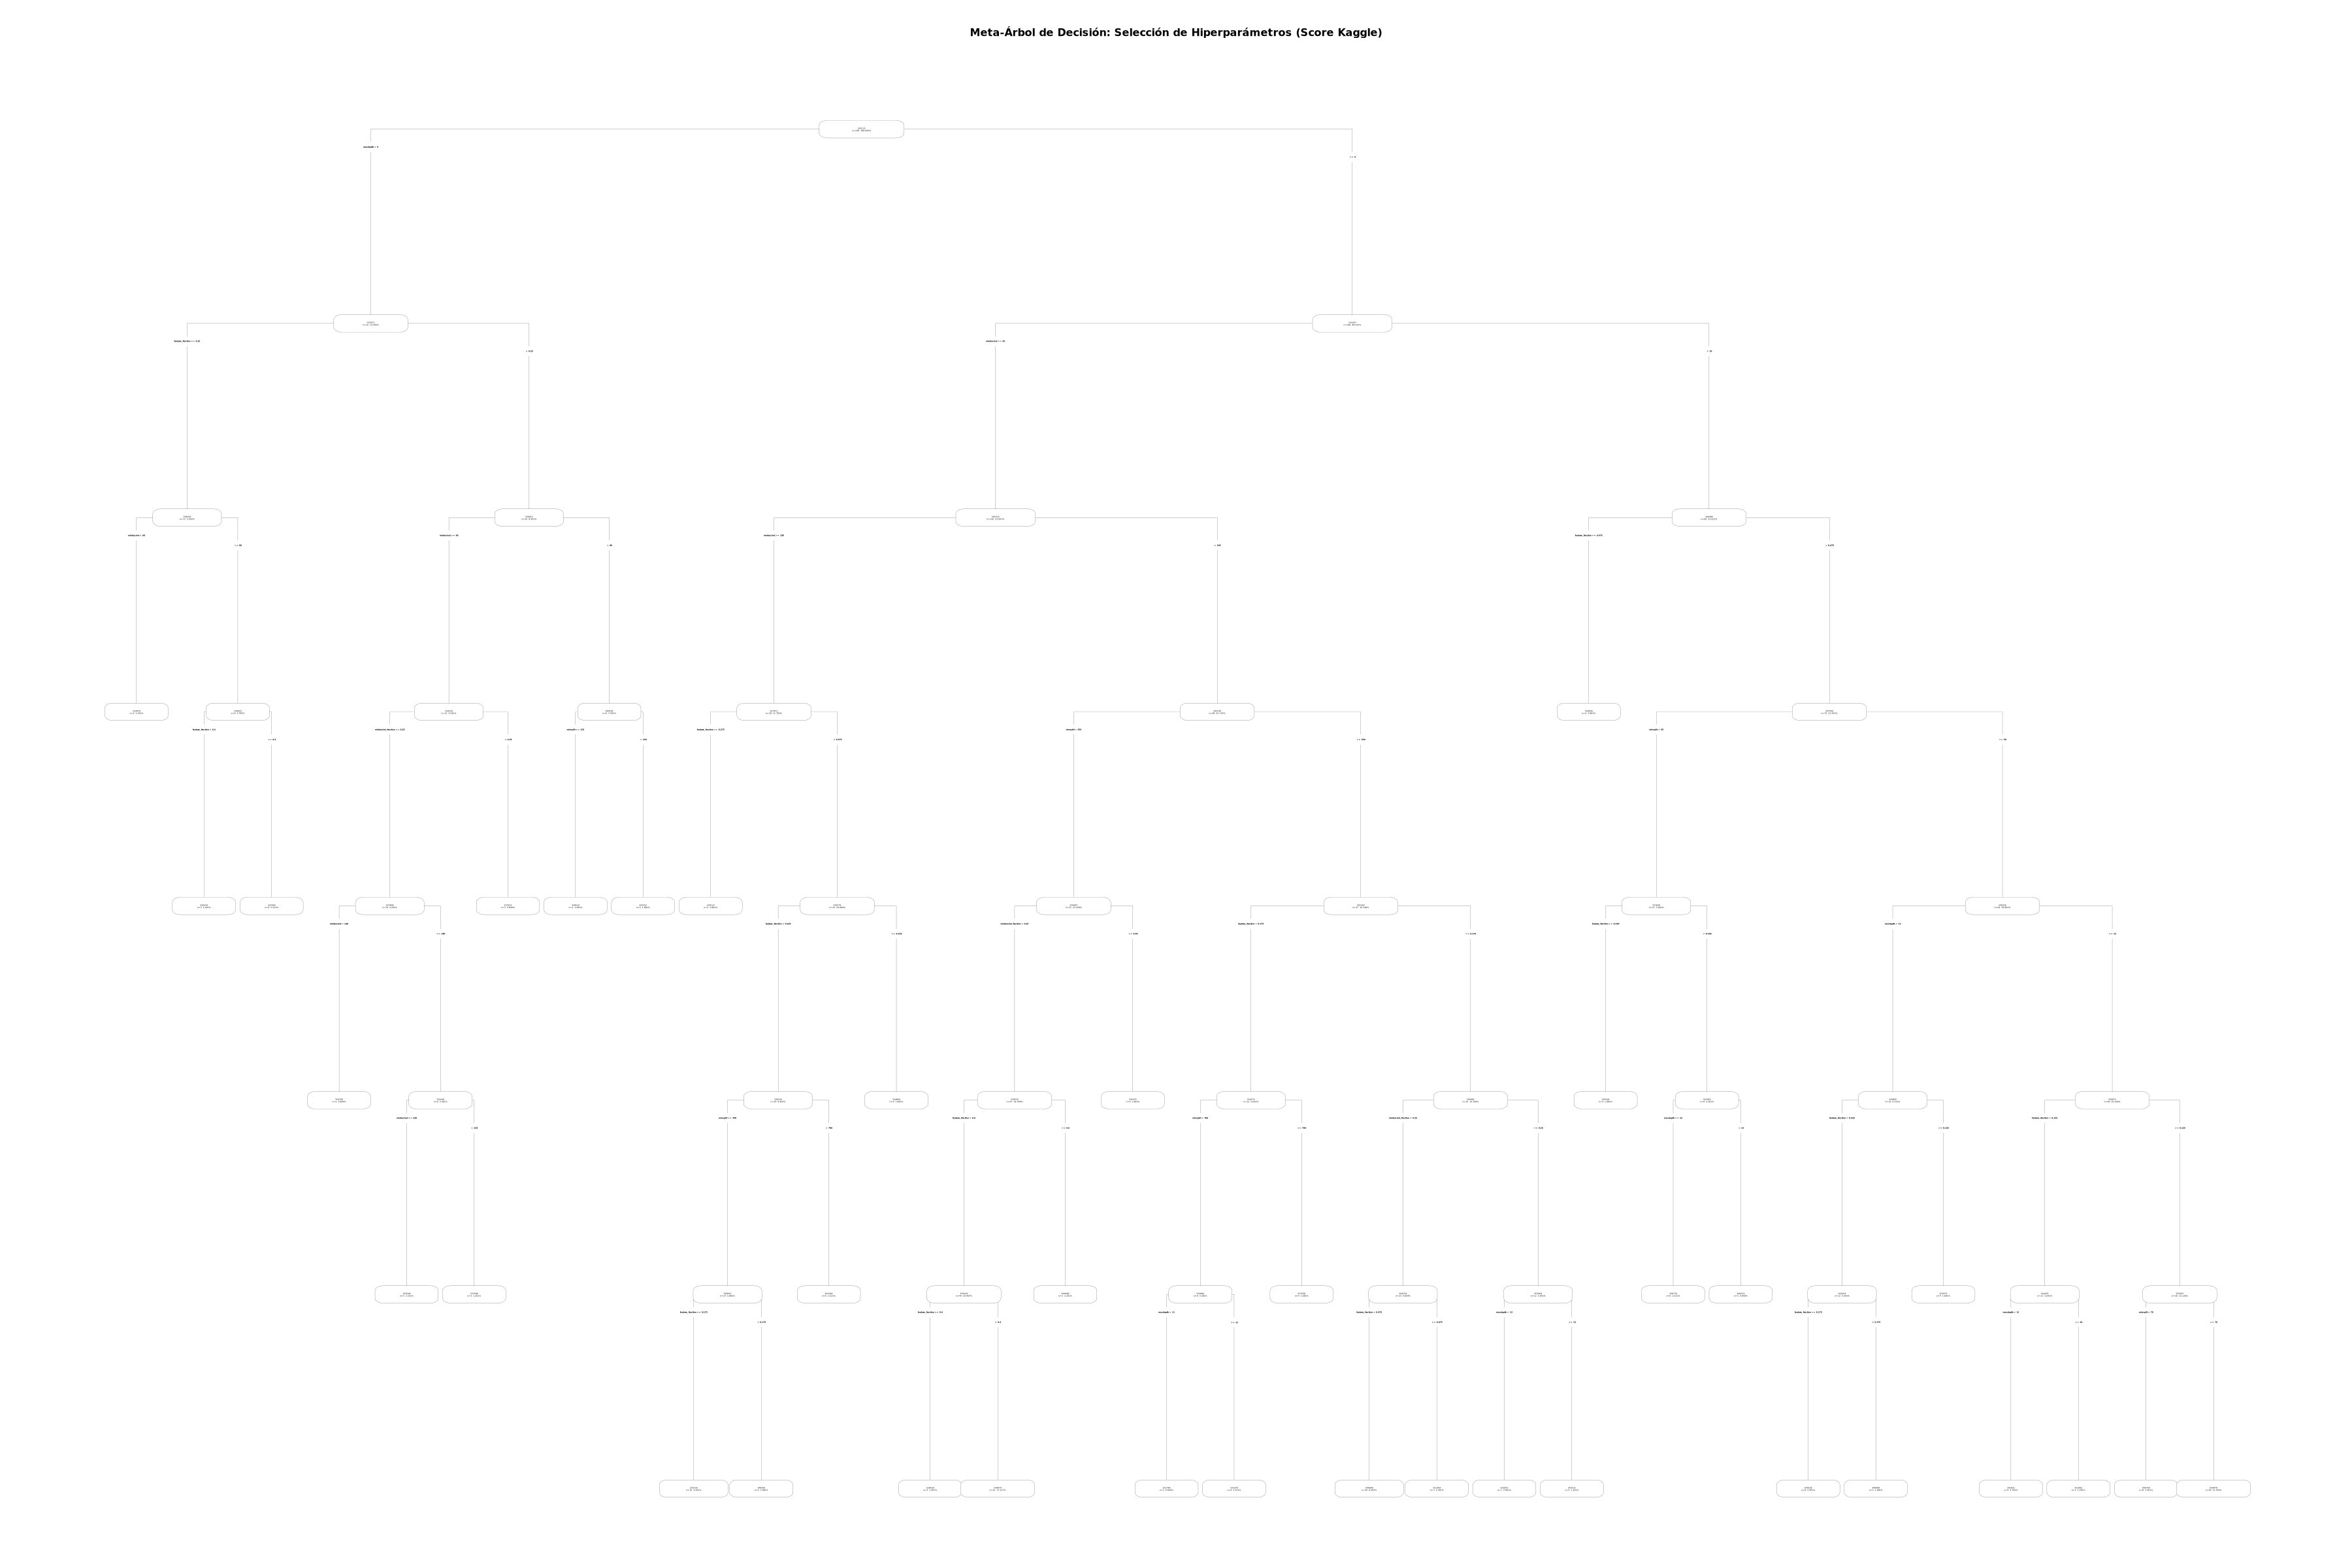

In [6]:
# Dimensiones de visualización en el notebook
options(repr.plot.width = 30, repr.plot.height = 20)

# Gráfico usando prp (estilo aa102_FinalTrain.ipynb)
prp(modelo_final,
    extra = 101,
    digits = -5,
    branch = 1,
    type = 4,
    varlen = 0,
    faclen = 0,
    main = "Meta-Árbol de Decisión: Selección de Hiperparámetros (Score Kaggle)"
)

#### 7. Guardado del Gráfico en Archivo PDF y Visualización con `rpart.plot`

pdf 
  2

Gráfico del árbol guardado exitosamente en: /workspace/datasets/meta_arbol_hiperparametros.pdf



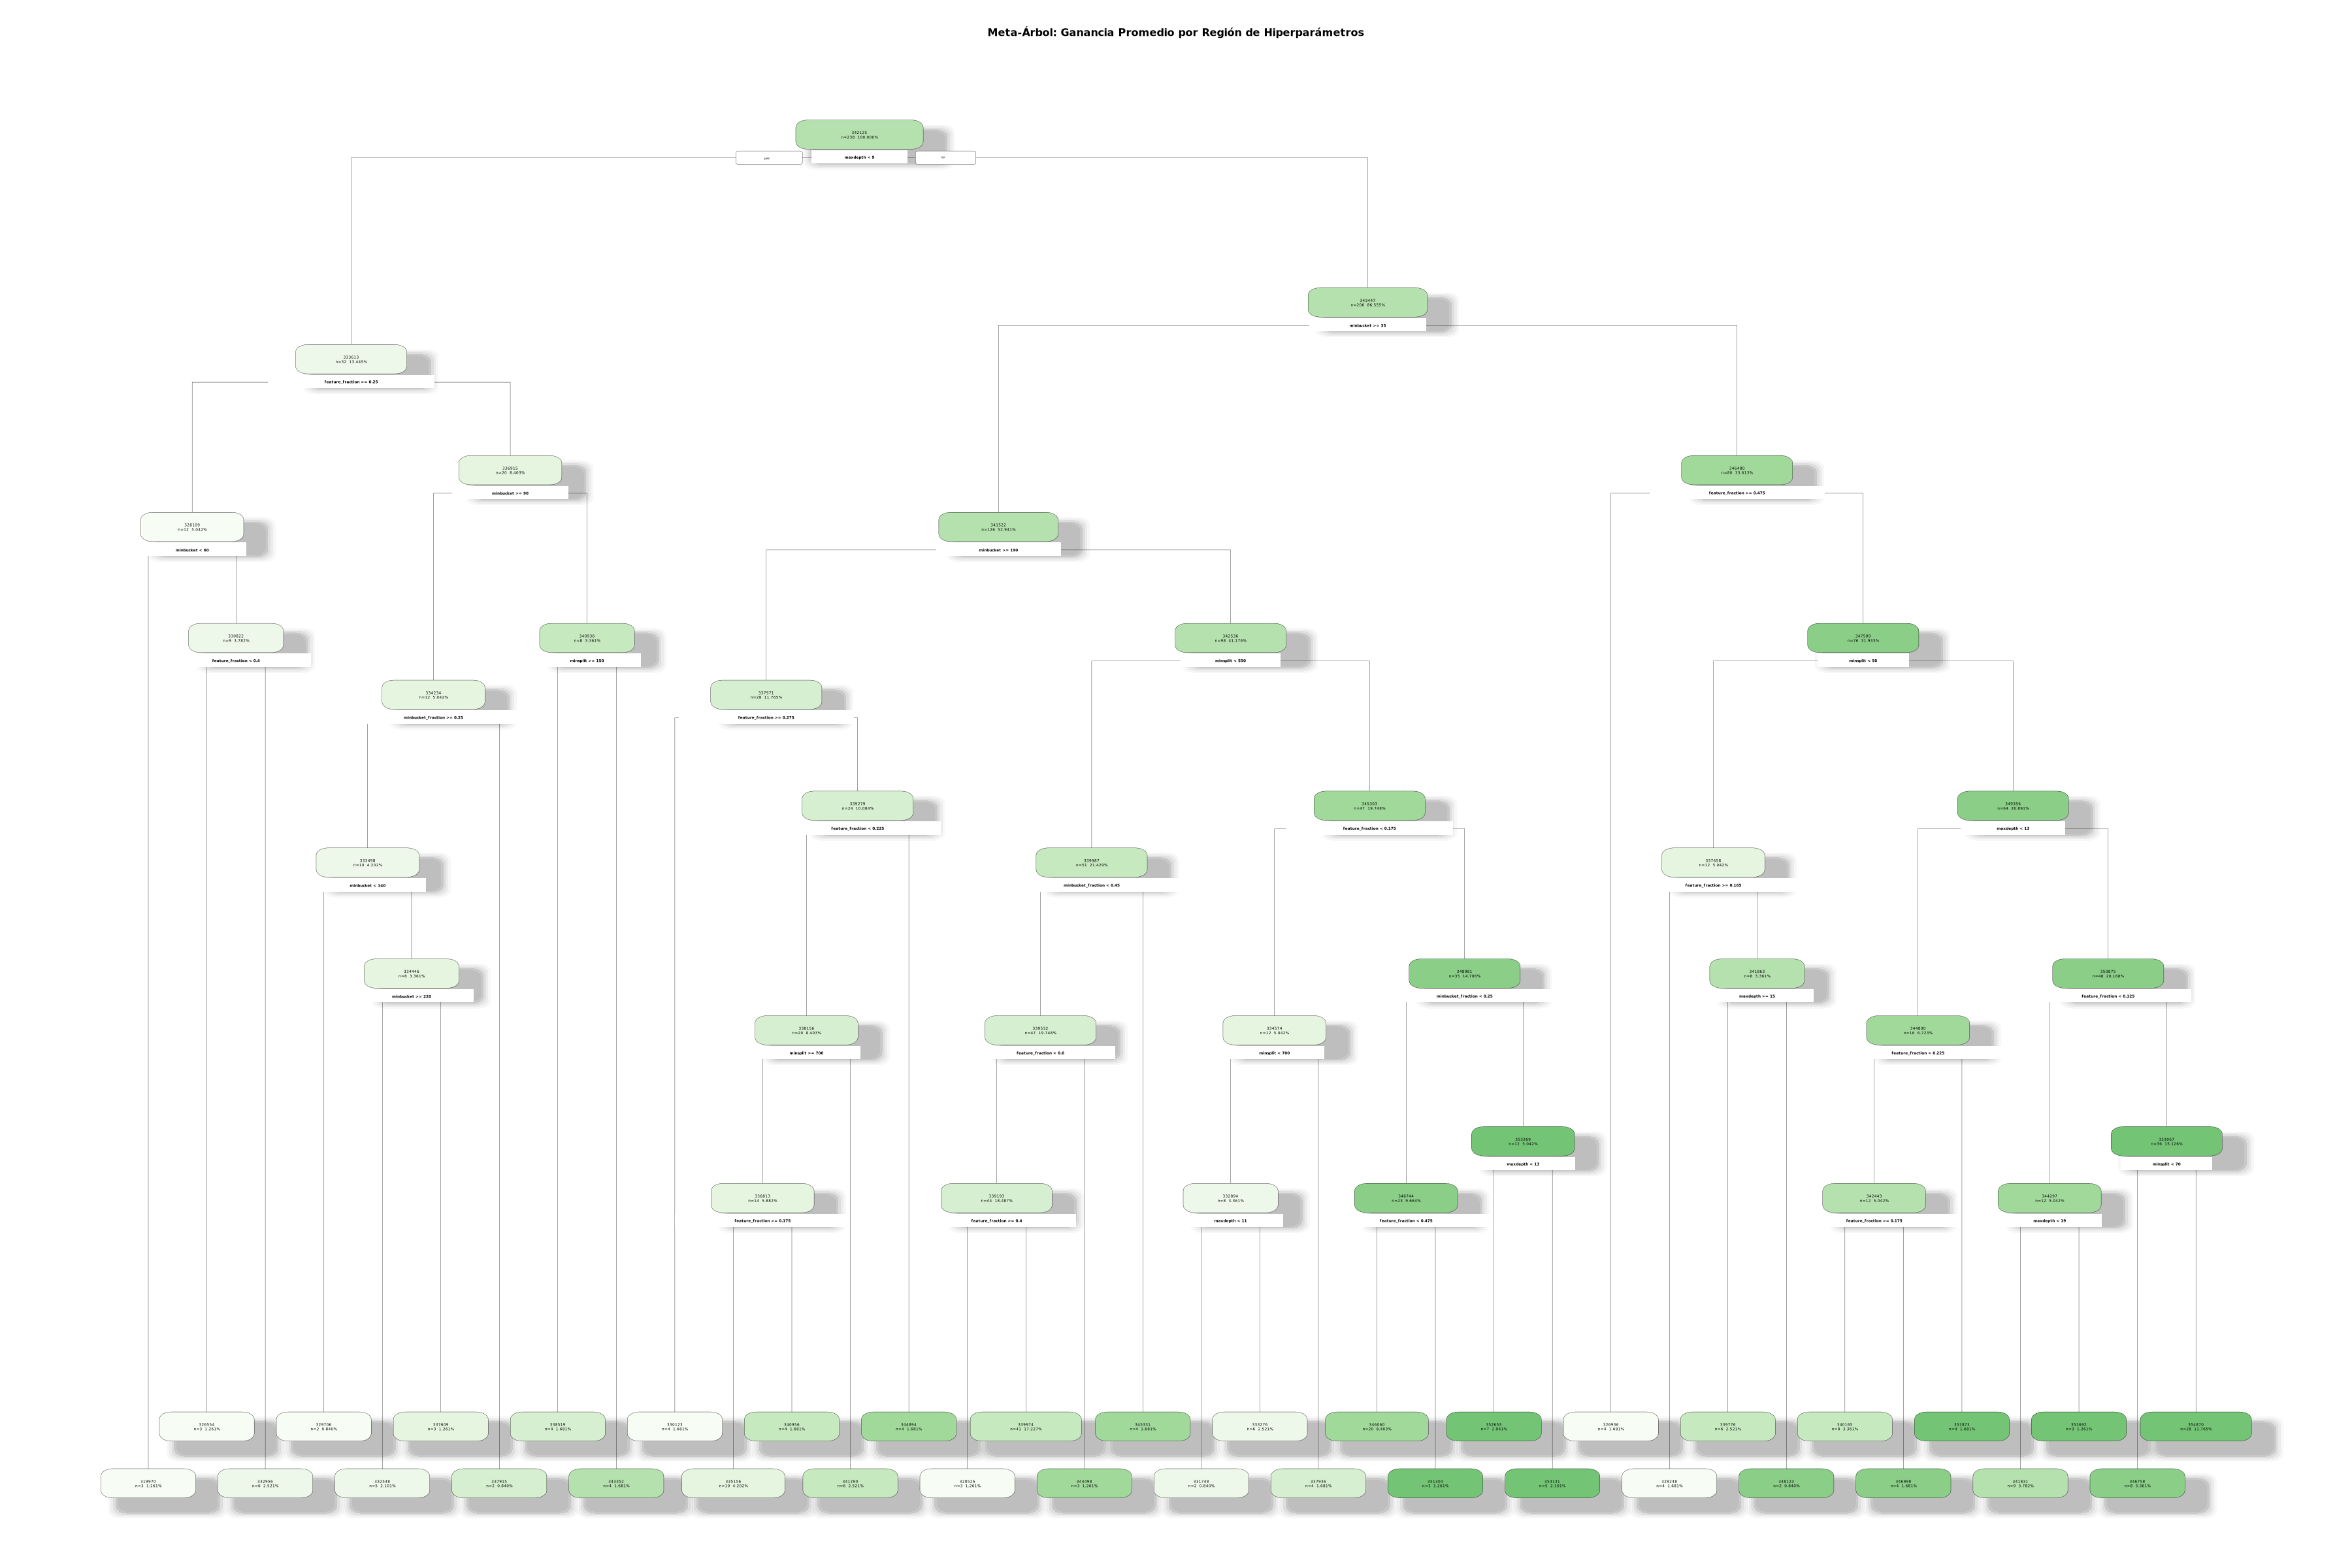

In [7]:
# Guardar en PDF de alta resolución en la carpeta de datasets
pdf_destino <- file.path(dir_base, "datasets", "meta_arbol_hiperparametros.pdf")
pdf(pdf_destino, width = 18, height = 12)
prp(modelo_final,
    extra = 101,
    digits = 6,
    branch = 1,
    type = 4,
    varlen = 0,
    faclen = 0,
    main = "Meta-Árbol de Decisión: Selección de Hiperparámetros (Score Kaggle)"
)
dev.off()
cat(sprintf("Gráfico del árbol guardado exitosamente en: %s\n\n", pdf_destino))

# Visualización con rpart.plot (con hojas caídas y paleta de colores)
rpart.plot(modelo_final,
  type = 2,
  extra = 101,
  digits = -5,
  fallen.leaves = TRUE,
  box.palette = "Greens",
  shadow.col = "gray",
  main = "Meta-Árbol: Ganancia Promedio por Región de Hiperparámetros"
)

#### 8. Análisis de las Mejores Regiones de Hiperparámetros (Top Hojas)

In [8]:
# Asignar a cada corrida el número de nodo/hoja correspondiente
dtrain_final[, nodo := modelo_final$where]

# Resumen de desempeño por hoja terminal
resumen_hojas <- dtrain_final[, .(
  cant_corridas = .N,
  score_promedio = round(mean(score), 1),
  score_maximo = max(score),
  score_minimo = min(score),
  ff_prom = round(mean(feature_fraction), 2),
  maxdepth_prom = round(mean(maxdepth), 1),
  minsplit_prom = round(mean(minsplit), 1),
  minbucket_prom = round(mean(minbucket), 1)
), by = nodo][order(-score_promedio)]

cat("Ranking de Hojas Terminales (de mayor a menor score promedio):\n")
print(resumen_hojas)

cat("\nTop 5 mejores corridas individuales del dataset:\n")
print(head(dataset[order(-score), .(experimento, iter, feature_fraction, maxdepth, minsplit, minbucket_fraction, minbucket, score, envios_positivos, archivo)], 5))

format(Sys.time(), "%a %b %d %X %Y")

Ranking de Hojas Terminales (de mayor a menor score promedio):
     nodo cant_corridas score_promedio score_maximo score_minimo ff_prom
    <int>         <int>          <num>        <int>        <int>   <num>
 1:    71            28       354870.1       368248       342165    0.18
 2:    50             5       354131.4       355581       352665    0.32
 3:    49             7       352652.7       353581       351748    0.29
 4:    64             4       351873.0       353831       350998    0.25
 5:    68             3       351692.3       354248       349498    0.10
 6:    47             3       351303.7       354581       349415    0.70
 7:    58             2       348123.0       354831       341415    0.12
 8:    63             4       346998.2       353165       336998    0.15
 9:    70             8       346758.4       357165       332581    0.16
10:    46            20       346060.5       351415       339831    0.22
11:    37             4       345331.2       347748       341

[1] "Mon Aug 24 15:36:30 2026"